In [61]:
# trying to set up a CVX problem
import cvxpy
import numpy as np
from hsa_hopper.kinematics import *
from hsa_hopper.collocation import interp_covector
from scipy.sparse import bsr_array
import pandas as pd

class RegDiffer:
    def __init__(self):
        pass
    """
    Create a sparse linear operator that evaluates C1 continuity
    on a quadratic spline of the motor angle measurements.
    """ 
    def _eq_const_sparse_op(self, df):
        t = df['t_s'].to_numpy()
        N = t.size
        rows = 2*(N-2)
        cols = 3*(N-1)
        nnz = 6*(2*(N-2))
        data = np.zeros(nnz)
        rowptr = np.zeros(nnz, dtype=np.int32)
        colptr = np.zeros(nnz, dtype=np.int32)

        for i in range(1,N-1):
            t0 = interp_covector(t[i],t[i-1],t[i],3)
            dt0 = interp_covector(t[i],t[i-1],t[i],3,ord=1)
            t1 = interp_covector(t[i],t[i],t[i+1],3)
            dt1 = interp_covector(t[i],t[i],t[i+1],3,ord=1)
            for j in range(3):

                row = np.ravel_multi_index((i-1,0),(N-2,2),order='C')
                col = np.ravel_multi_index((i-1,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,0,0),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = -t0[0,j]

                col = np.ravel_multi_index((i,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,1,0),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = t1[0,j]

                row = np.ravel_multi_index((i-1,1),(N-2,2),order='C')
                col = np.ravel_multi_index((i-1,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,0,1),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = -dt0[0,j]

                col = np.ravel_multi_index((i,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,1,1),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = dt1[0,j]
        return bsr_array((data,(rowptr,colptr)),shape=(rows,cols))

    """
    Creates a sparse linear operator that evaluates the spline at each
    time step. The keywork argument ord determines the order of differentiation.
    """
    def _interp_sparse_op(self, df, ord=0):
        t = df['t_s'].to_numpy()
        rows = t.size
        cols = 3*(t.size-1)
        nnz = (3-ord)*t.size
        data = np.zeros(nnz)
        rowptr = np.zeros(nnz, dtype=np.int32)
        colptr = np.zeros(nnz, dtype=np.int32)
        for i in range(t.size-1):
            if i == 0:
                covec = interp_covector(t[0],t[0],t[1],3,ord=ord)
                interp_idx = (3-ord)*[0], list(range(ord,3))
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[:(3-ord)] = covec[0,ord:]
                rowptr[:(3-ord)] = 0
                colptr[:(3-ord)] = col_idx

                covec = interp_covector(t[1],t[0],t[1],3,ord=ord)
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[(3-ord):2*(3-ord)] = covec[0,ord:]
                rowptr[(3-ord):2*(3-ord)] = 1
                colptr[(3-ord):2*(3-ord)] = col_idx
            else:
                covec = interp_covector(t[i+1],t[i],t[i+1],3,ord=ord)
                interp_idx = (3-ord)*[i], list(range(ord,3))
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[(3-ord)*(i+1):(3-ord)*(i+2)] = covec[0,ord:]
                rowptr[(3-ord)*(i+1):(3-ord)*(i+2)] = i+1
                colptr[(3-ord)*(i+1):(3-ord)*(i+2)] = col_idx
        return bsr_array((data,(rowptr,colptr)),shape=(rows,cols))
    
    def diff_x(self, df, weights):
        eq_const_op = self._eq_const_sparse_op(df)
        pos_linop = self._interp_sparse_op(df,ord=0)
        vel_linop = self._interp_sparse_op(df,ord=1)
        acc_linop = self._interp_sparse_op(df,ord=2)
        x = df['x_rad'].to_numpy()
        t = df['t_s'].to_numpy()
        tdiff = np.diff(t)
        vars = cvxpy.Variable(3*(t.size-1))

        pos = pos_linop@vars
        pos_err = pos-x
        # vel = vel_linop@vars
        # vel_err = vel[:-1]-xdot_fdiff
        acc = acc_linop@vars
        acc_diffs = cvxpy.diff(acc)

        pos_cost = cvxpy.sum_squares(pos_err)
        # vel_cost = cvxpy.sum_squares(cvxpy.multiply(vel_err,tdiff))
        # vel_cost = cvxpy.sum_squares(vel_err)

        if weights[1] == 0:
            l1_cost = 0
        else:
            l1_cost = cvxpy.sum(cvxpy.multiply(cvxpy.abs(acc_diffs),tdiff))
        if weights[2] == 0:
            l2_cost = 0
        else:
            l2_cost = cvxpy.sum(cvxpy.multiply(cvxpy.power(acc_diffs,2),tdiff))
        cost = weights[0]*(pos_cost) + weights[1]*l1_cost + weights[2]*l2_cost
        constraints = [eq_const_op@vars == 0]
        prob = cvxpy.Problem(cvxpy.Minimize(cost), constraints)

        if prob.is_dcp():
            # print('Solving regularized differentiation problem')
            prob.solve()
            coeffs = vars.value
            pos = pos_linop@coeffs
            vel = vel_linop@coeffs
            acc = acc_linop@coeffs
            return pos, vel, acc
        else:
            # print(f'Differentiation problem is not DCP?')
            return None, None, None

    def smooth_tau(self, df, weights):
        tau = df['torque'].to_numpy()
        t = df['t_s'].to_numpy()
        vars = cvxpy.Variable(t.size)

        errors = tau - vars
        diffs = vars[:-1]-vars[1:]

        square_errors = cvxpy.power(errors,2)
        sos_errors = cvxpy.sum(square_errors)
        if weights[1] == 0:
            l1_cost = 0
        else:
            l1_cost = cvxpy.sum(cvxpy.abs(diffs))
        if weights[2] == 0:
            l2_cost = 0
        else:
            l2_cost = cvxpy.sum(cvxpy.power(diffs,2))

        cost = weights[0]*sos_errors+weights[1]*l1_cost + weights[2]*l2_cost
        prob = cvxpy.Problem(cvxpy.Minimize(cost))

        if prob.is_dcp():
            # print('Solving smoothing problem')
            prob.solve()
            return vars.value

In [68]:
import os
import yaml
from hsa_hopper.kinematics import *
from hsa_hopper.controller import HopController
kin_params = KinematicParameters(.07,.15,.3,-.005)
root_dir = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\design_paper'
differ = RegDiffer()
for experiment_path in os.listdir(root_dir):
    experiment_dir = os.path.join(root_dir, experiment_path)
    for trial_path in os.listdir(experiment_dir):
        trial_dir = os.path.join(experiment_dir, trial_path)
        hop_frames = []
        hop_idx = []
        for file_path in os.listdir(trial_dir):
            if 'hop' not in file_path:
                continue
            idx = int(file_path.split('_')[1][:-4])
            print(f'Processing hop #{idx} of trial {trial_path} in category {experiment_path}')
            df = pd.read_csv(os.path.join(trial_dir,file_path))

            # filter stance data
            # frame = (df['mode'] == HopController._STANCE) | (df['mode'] == HopController._STARTUP)
            # CAUTION: only use the line below on data from the first paper
            frame = (df['mode'] == 2) | (df['mode'] == 3)
            if sum(frame) <= 10:
                print(f'Stance phase of hop {idx} is too short, possible controller data. Skipping this frame.')
                continue 
            x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            tau_raw = df.loc[frame,'torque'].to_numpy(copy=True)
            x, xdot, xddot = differ.diff_x(df.loc[frame,:], [1,0,5e-4])
            tau = differ.smooth_tau(df.loc[frame,:], [1,0,50])
            fk,jac,hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            df.loc[frame,'x_raw'] = x_raw
            df.loc[frame,'x_rad'] = x
            df.loc[frame,'xdot'] = xdot
            df.loc[frame,'xddot'] = xddot
            df.loc[frame,'torque'] = tau
            df.loc[frame,'torque_raw'] = tau_raw
            df.loc[frame,'y_m'] = fk[0]
            df.loc[frame,'ydot'] = jac[0]*xdot
            df.loc[frame,'yddot'] = jac[0]*xddot + xdot*hess[0]*xdot
            df.loc[frame,'l_m'] = fk[1]
            df.loc[frame,'ldot'] = jac[1]*xdot
            df.loc[frame,'lddot'] = jac[1]*xddot + xdot*hess[1]*xdot
            df.loc[frame,'dydx'] = jac[0]
            df.loc[frame,'dldx'] = jac[1]
            df.loc[frame,'d2yd2x'] = hess[0]
            df.loc[frame,'d2ld2x'] = hess[1]

            frame = (df['mode'] == HopController._FLIGHT)
            if sum(frame) <= 10:
                print(f'Flight phase of hop {idx} is too short, possible controller data. Skipping this frame.')
                continue
            x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            tau_raw = df.loc[frame,'torque'].to_numpy(copy=True)
            x, xdot, xddot = differ.diff_x(df.loc[frame,:], [1,0,5e-4])
            tau = differ.smooth_tau(df.loc[frame,:], [1,0,50])
            fk,jac,hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            df.loc[frame, 'x_raw'] = x_raw
            df.loc[frame, 'x_rad'] = x
            df.loc[frame, 'xdot'] = xdot
            df.loc[frame, 'xddot'] = xddot
            df.loc[frame, 'torque'] = tau
            df.loc[frame, 'torque_raw'] = tau_raw
            df.loc[frame, 'y_m'] = fk[0]
            df.loc[frame, 'ydot'] = jac[0]*xdot
            df.loc[frame, 'yddot'] = jac[0]*xddot + xdot*hess[0]*xdot
            df.loc[frame, 'l_m'] = fk[1]
            df.loc[frame, 'ldot'] = jac[1]*xdot
            df.loc[frame, 'lddot'] = jac[1]*xddot + xdot*hess[1]*xdot
            df.loc[frame, 'dydx'] = jac[0]
            df.loc[frame, 'dldx'] = jac[1]
            df.loc[frame, 'd2yd2x'] = hess[0]
            df.loc[frame, 'd2ld2x'] = hess[1]
            hop_idx.append(idx)
            df['hop_idx'] = idx
            hop_frames.append(df)
        trial_df = pd.concat([hop_frames[i] for i in np.argsort(hop_idx)])
        # print(f'Processing trial {trial_path} of experiment {experiment_path}')
        # x_raw = trial_df['x_rad'].to_numpy(copy=True)
        # tau_raw = trial_df['torque'].to_numpy(copy=True)
        # x, xdot, xddot = differ.diff_x(trial_df, [1,0,1e-3])
        # tau = differ.smooth_tau(trial_df, [1,0,100])
        # print(f'Data smoothing complete')
        trial_df.to_csv(os.path.join(trial_dir, 'data.csv'))

Processing hop #0 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #1 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #10 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #11 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #12 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #13 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #14 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #15 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #16 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #17 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #18 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #19 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #2 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #20 of trial hsa_1300g_52mm_avg in category hsa_1300g
Processing hop #21 of trial hsa_1300g

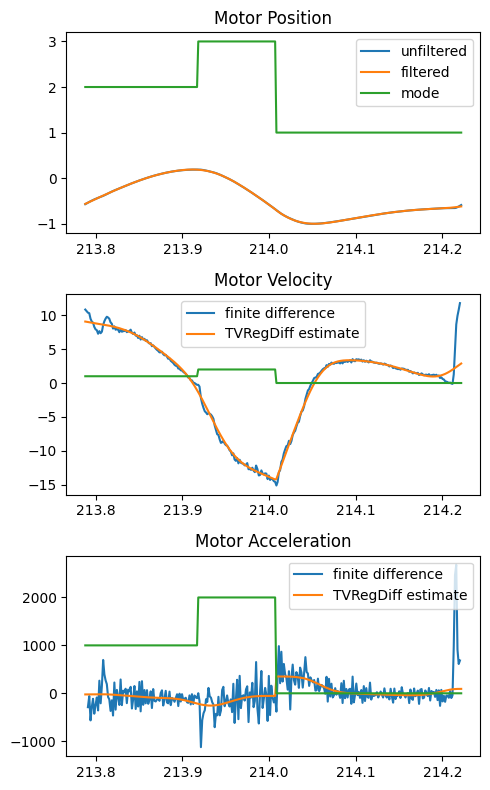

In [69]:
frame = (15 <= trial_df['hop_idx']) & (trial_df['hop_idx'] <= 15)
x = trial_df.loc[frame,'x_rad'].to_numpy()
x_raw = trial_df.loc[frame,'x_raw'].to_numpy()
xdot = trial_df.loc[frame,'xdot'].to_numpy()
xddot = trial_df.loc[frame,'xddot'].to_numpy()
t = trial_df.loc[frame,'t_s'].to_numpy()
mode = trial_df.loc[frame,'mode'].to_numpy()
fig,axs = plt.subplots(nrows=3,figsize=(5,8))
axs[0].plot(t,x_raw,label='unfiltered')
axs[0].plot(t,x,label='filtered')
axs[0].plot(t,mode,label='mode')
axs[0].legend()
axs[0].set_title('Motor Position')
axs[1].plot(t[:-1],np.diff(x_raw)/np.diff(t),label='finite difference')
axs[1].plot(t,xdot,label='TVRegDiff estimate')
axs[1].plot(t,mode-1)
axs[1].set_title('Motor Velocity')
axs[1].legend()
axs[2].plot(t[1:-1],np.diff(np.diff(x_raw)/np.diff(t))/np.diff(t[1:]),label='finite difference')
axs[2].plot(t,xddot,label='TVRegDiff estimate')
axs[2].plot(t,(mode-1)*1000)
axs[2].set_title('Motor Acceleration')
axs[2].legend()
fig.tight_layout()
fig.savefig('tvregdiff.png')

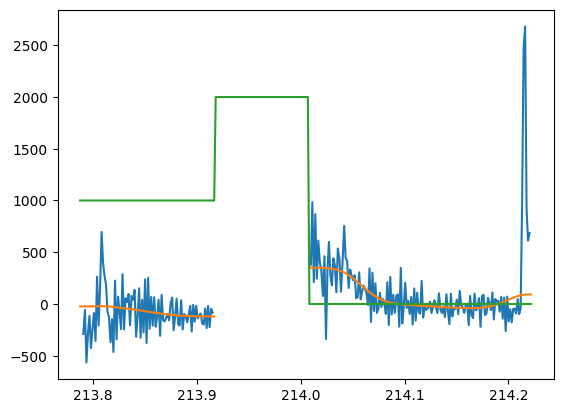

In [64]:

plt.plot(t[1:-1],np.diff(np.diff(x_raw)/np.diff(t))/np.diff(t[1:]),label='finite difference')
plt.plot(t,xddot,label='TVRegDiff estimate')
plt.plot(t,(mode-1)*1000)

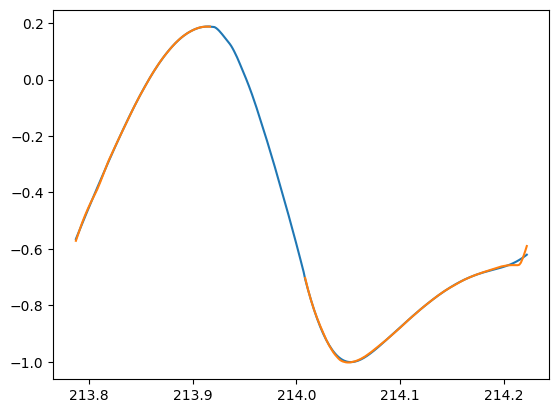

In [65]:
tau = trial_df.loc[frame,'torque'].to_numpy()
y = trial_df.loc[frame,'y_m'].to_numpy()
l = trial_df.loc[frame,'l_m'].to_numpy()
ydot = trial_df.loc[frame,'ydot'].to_numpy()
yddot = trial_df.loc[frame,'yddot'].to_numpy()
plt.plot(t,x)
plt.plot(t,x_raw)

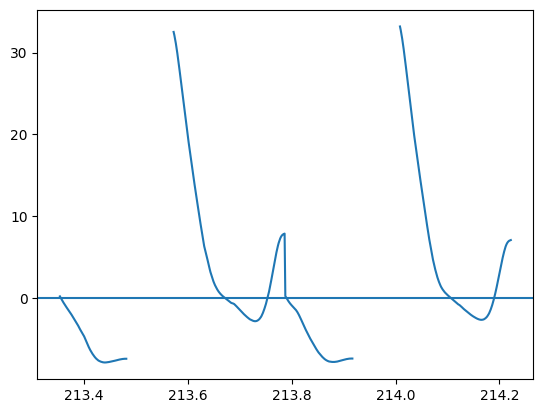

In [66]:

frame = (14 <= trial_df['hop_idx']) & (trial_df['hop_idx'] <= 15)
l = trial_df.loc[frame,'l_m'].to_numpy()
ldot = trial_df.loc[frame,'ldot'].to_numpy()
lddot = trial_df.loc[frame,'lddot'].to_numpy()
t = trial_df.loc[frame,'t_s'].to_numpy()
mode = trial_df.loc[frame,'mode'].to_numpy()
# plt.plot(t,ldot*100)
plt.plot(t,lddot)
# plt.plot(t,(mode)*50-75)
# plt.plot(t,ldot)
# plt.plot(t,(mode)-1.5)
plt.axhline(0)

In [67]:
for idx in trial_df['hop_idx'].unique():
    # find maximum acceleration in stance
    frame = (trial_df['hop_idx'] == idx) & (trial_df['mode'] == HopController._STANCE)
    lddot = trial_df.loc[frame, 'lddot'].to_numpy()
    stance_jerk = np.diff(lddot)
    stance_max_acc_idx = np.argmax(stance_jerk)
    frame = (trial_df['hop_idx'] == idx) & (trial_df['mode'] == HopController._FLIGHT)
    lddot = trial_df.loc[frame, 'lddot'].to_numpy()
    flight_jerk = np.diff(lddot)
    flight_max_acc_idx = np.argmax(stance_jerk)
    print((idx,stance_jerk[stance_max_acc_idx],flight_jerk[flight_max_acc_idx]))

(0, 0.13079113002785459, -0.06993862628957737)
(1, 0.10943331864635208, -0.43574524653493274)
(2, 0.029769570374304166, -0.057988895418108255)
(3, 0.0455009647061102, -0.07955594505481145)
(4, 0.025315496212672706, -0.07988502417838084)
(5, 0.02520108184793468, -0.08337656159432927)
(6, 0.023722666155416405, -0.06469808503389474)
(7, 0.025712057526658505, -0.06682118723197406)
(8, 0.03163333960561676, -0.06412077337564626)
(9, 0.040020570794956356, -0.06922323895730487)
(10, 0.03805580874804715, -0.07844919684006757)
(11, 0.024920017956938878, -0.058710750722443805)
(12, 0.0307255539226432, -0.07049488870800313)
(13, 0.03227596245636288, -0.09079482404467465)
(14, 0.025988402858187598, -0.09176787949437942)
(15, 0.026506742736292388, -0.08006393050894334)
(16, 0.0390915195971866, -0.07604388934452444)
(17, 0.03620585388071351, -0.08167488269584433)
(18, 0.020647936254223787, -0.08035581697138083)
(19, 0.0333221285468106, -0.0761648222232536)
(20, 0.030473499274839, -0.07758230125771481